# Ejemplo de entrenamiento para ClothML (versión PCA)
Este notebook corresponde al experimento de RNN con PCA y unrolling.

----
## 1. Carga de datos, elección de features

In [ ]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


output_path = 'miau' #Nombre para archivos generados (JSON, ONNX)
csv_path = 'data/clothDataset_107_' #Nombre del dataset de la simulación
df = pd.read_csv(csv_path + '.csv')

#Características de la tela
num_vertices = 25
num_features = 4  # x, y, z, sdf

df = df.drop(columns=['frame'])

selected_columns = []
for i in range(num_vertices):
    selected_columns.extend([f'x{i}', f'y{i}', f'z{i}', 
                             #f'vx{i}', f'vy{i}', f'vz{i}', 
                             f'sdf{i}'])
df = df[selected_columns]

## 2. Aplicación de PCA

Columnas totales usadas para PCA: 100
Componentes PCA óptimos (95% varianza): 16  [varianza explicada: 95.25%]


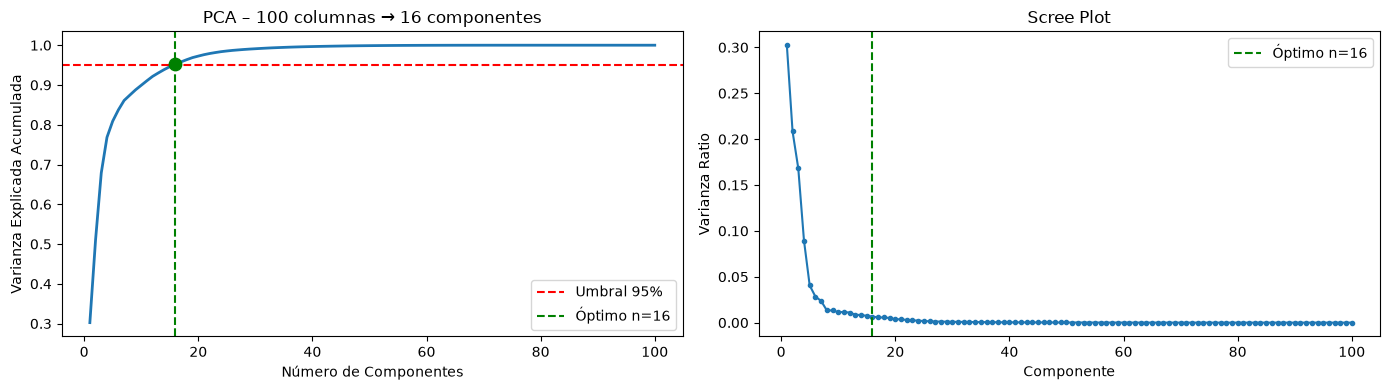

Forma train: (20004, 100) → (20004, 16)
Forma test:  (5001, 100)  → (5001, 16)
Tensor entrada PCA train: torch.Size([20004, 1, 16])
Tensor entrada PCA test:  torch.Size([5001, 1, 16])
Tensor XYZ train:         torch.Size([20004, 25, 3])
Tensor XYZ test:          torch.Size([5001, 25, 3])
SDF tensor train: torch.Size([20004, 25])
SDF tensor test:  torch.Size([5001, 25])


In [12]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

num_frames   = df.shape[0]

data_flat_raw = df.values  # (N, num_vertices*13)
total_columns = data_flat_raw.shape[1]
print(f"Columnas totales usadas para PCA: {total_columns}")

# Split cronológico para train y test
train_size = int(0.8 * num_frames)
data_train_raw = data_flat_raw[:train_size]
data_test_raw  = data_flat_raw[train_size:]

# Scale train data
input_scaler = StandardScaler()
data_train_scaled = input_scaler.fit_transform(data_train_raw)
data_test_scaled  = input_scaler.transform(data_test_raw)

# PCA train data
pca_search = PCA()
pca_search.fit(data_train_scaled)
cumvar = pca_search.explained_variance_ratio_.cumsum()
optimal_n = int(np.argmax(cumvar >= 0.95)) + 1
print(f"Componentes PCA óptimos (95% varianza): {optimal_n}  "
      f"[varianza explicada: {cumvar[optimal_n-1]:.2%}]")

# Figuras 
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(range(1, len(cumvar)+1), cumvar, linewidth=2)
axes[0].axhline(y=0.95, color='r', linestyle='--', label='Umbral 95%')
axes[0].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[0].scatter([optimal_n], [cumvar[optimal_n-1]], color='g', zorder=5, s=80)
axes[0].set_xlabel('Número de Componentes')
axes[0].set_ylabel('Varianza Explicada Acumulada')
axes[0].set_title(f'PCA – {total_columns} columnas → {optimal_n} componentes')
axes[0].legend()
axes[1].plot(range(1, len(pca_search.explained_variance_ratio_)+1),
             pca_search.explained_variance_ratio_, 'o-', markersize=3)
axes[1].axvline(x=optimal_n, color='g', linestyle='--', label=f'Óptimo n={optimal_n}')
axes[1].set_xlabel('Componente')
axes[1].set_ylabel('Varianza Ratio')
axes[1].set_title('Scree Plot')
axes[1].legend()
plt.tight_layout()
plt.show()

# PCA sobre train y test escalados
input_pca = PCA(n_components=optimal_n)
data_train_pca = input_pca.fit_transform(data_train_scaled)  # (N_train, optimal_n)
data_test_pca  = input_pca.transform(data_test_scaled)       # (N_test,  optimal_n)

print(f"Forma train: {data_train_raw.shape} → {data_train_pca.shape}")
print(f"Forma test:  {data_test_raw.shape}  → {data_test_pca.shape}")

# Clipping sobre resultados PCA contenidos
pca_min = torch.tensor(data_train_pca.min(axis=0), dtype=torch.float32)
pca_max = torch.tensor(data_train_pca.max(axis=0), dtype=torch.float32)

# Extraer XYZ real para calcular target deltas
xyz_cols = []
for i in range(num_vertices):
    xyz_cols.extend([f'x{i}', f'y{i}', f'z{i}'])
data_xyz = df[xyz_cols].values  # (N, num_vertices*3)
data_xyz_3d = data_xyz.reshape(num_frames, num_vertices, 3)
xyz_tensor = torch.tensor(data_xyz_3d, dtype=torch.float32)

# Splits XYZ alineados con splits PCA
xyz_train = xyz_tensor[:train_size]
xyz_test  = xyz_tensor[train_size:]

# Tensores (N, 1, optimal_n)
data_train_tensor = torch.tensor(data_train_pca.reshape(-1, 1, optimal_n), dtype=torch.float32)
data_test_tensor  = torch.tensor(data_test_pca.reshape(-1, 1, optimal_n),  dtype=torch.float32)

print(f"Tensor entrada PCA train: {data_train_tensor.shape}")
print(f"Tensor entrada PCA test:  {data_test_tensor.shape}")
print(f"Tensor XYZ train:         {xyz_train.shape}")
print(f"Tensor XYZ test:          {xyz_test.shape}")

# Extraer SDF real por vértice para el fix del rollout  (SDF siempre será real)
sdf_cols = [f'sdf{i}' for i in range(num_vertices)]
data_sdf = df[sdf_cols].values                            # (N, num_vertices)
data_sdf_tensor = torch.tensor(data_sdf, dtype=torch.float32)
sdf_train = data_sdf_tensor[:train_size]
sdf_test  = data_sdf_tensor[train_size:]
print(f"SDF tensor train: {sdf_train.shape}")
print(f"SDF tensor test:  {sdf_test.shape}")


## 3. Datasets
Loaders,  normalización

In [ ]:
import ClothDataset
from Normalization import NormPCA

seq_length = 16
batch_size = 32
ROLLOUT_STEPS = 24

# Creación de los datasets de tipo Cloth
train_dataset = ClothDataset.ClothPCADataset(data_train_tensor, xyz_train, sdf_train, seq_len=seq_length, rollout_steps=ROLLOUT_STEPS)
test_dataset  = ClothDataset.ClothPCADataset(data_test_tensor,  xyz_test,  sdf_test,  seq_len=seq_length, rollout_steps=ROLLOUT_STEPS)

# Data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

for batch_seq, batch_future_xyz, batch_future_sdf, batch_future_pca in train_loader:
    print(f"Entrada RNN (PCA):    {batch_seq.shape}")          # [B, seq_len, 1, optimal_n]
    print(f"XYZ futuros:          {batch_future_xyz.shape}")   # [B, seq_len+1, V, 3]
    print(f"SDF futuros:          {batch_future_sdf.shape}")   # [B, seq_len+1, V]
    print(f"PCA futuros:          {batch_future_pca.shape}")   # [B, seq_len+1, 1, optimal_n]
    break

# Normalización
norm_data = NormPCA(train_loader, input_scaler, input_pca, optimal_n, num_vertices, num_features, data_train_pca)
norm_data.save_stats_JSON("itried")

print(type(norm_data.pca_components), norm_data.pca_components.dtype if hasattr(norm_data.pca_components, "dtype") else None)
print(type(norm_data.pca_mean))
print(type(norm_data.input_scaler_std))
print(type(norm_data.input_scaler_mean))
print(type(norm_data.pca_min), type(norm_data.pca_max))


Entrada RNN (PCA):    torch.Size([32, 16, 1, 16])
XYZ futuros:          torch.Size([32, 25, 25, 3])
SDF futuros:          torch.Size([32, 25, 25])
PCA futuros:          torch.Size([32, 25, 1, 16])


## 4. Modelo

In [ ]:
import torch
import numpy as np
import torch.nn as nn
from Modelos import FlatRNNClothUnityPCA

#device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Por el momento GPU está deshabilitado en la reestructuración de código
device = "cpu"
print(f"Usando device: {device}")

# Modelo
model     = FlatRNNClothUnityPCA(n_pca_components=optimal_n, hidden_size=128)
model     = model.to(device)
criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)
scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.999)

total_params = sum(p.numel() for p in model.parameters())
print(f"Modelo creado | input={optimal_n} | output={optimal_n} (delta PCA)")
print(f"Parámetros totales: {total_params:,}")


Usando device: cpu
itried.json
<class 'torch.Tensor'> torch.float32
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>
<class 'torch.Tensor'> <class 'torch.Tensor'>
Modelo creado | input=16 | output=16 (delta PCA)
Parámetros totales: 20,752


## 5. Funciones auxiliares para el entrenamiento
Técnica de rollout y obtención de xyz a partir de un valor de subespacio

In [ ]:
def pca_to_xyz(pca_vec):
    """
    Transforma valores de espacio PCA a coordenadas xyz local
    pca_vec : [B, optimal_n]
    return  : [B, V, 3]
    """
    scaled = pca_vec @ norm_data.pca_components + norm_data.pca_mean   # [B, raw_size]  inverse PCA
    raw    = scaled * norm_data.input_scaler_std + norm_data.input_scaler_mean  # [B, raw_size]  inverse scaler 
    return raw.view(-1, num_vertices, num_features)[:, :, :3]  # [B, V, 3] (= xyz)


def run_rollout(batch_seq_pca, batch_future_xyz, batch_future_sdf, batch_future_pca,
                add_noise=False):
    """
    Aplica la técnica de unfolding/unrolling sobre un batch PCA 
    batch_seq_pca    : [B, seq_len, 1, optimal_n]
    batch_future_xyz : [B, W+1, V, 3]
    batch_future_sdf : [B, W+1, V]
    batch_future_pca : [B, W+1, 1, optimal_n] = targets en espacio PCA
    """
    B = batch_seq_pca.shape[0]
    W = batch_future_xyz.shape[1] - 1

    window_pca = batch_seq_pca.clone()
    if add_noise:
        window_pca = window_pca + torch.randn_like(window_pca) * NOISE_SIGMA

    total_loss    = torch.tensor(0.0)
    prev_pred_xyz = pca_to_xyz(window_pca[:, -1, 0, :])  # [B, V, 3]

    for step in range(W):
        pred_pca_delta_norm = model(window_pca)              # [B, optimal_n]

        # Desnormalizar delta PCA y actualizar estado PCA
        pred_pca_delta = pred_pca_delta_norm * norm_data.target_pca_std + norm_data.target_pca_mean
        current_pca    = window_pca[:, -1, 0, :]             # [B, optimal_n]
        pred_pca_next  = current_pca + pred_pca_delta        # [B, optimal_n]

        # Clipping 
        pred_pca_next = pred_pca_next.clamp(min=pca_min, max=pca_max)
        # Reconstruir XYZ desde el estado PCA predicho
        pred_xyz = pca_to_xyz(pred_pca_next)

        # Loss pos (deltas PCA)
        real_pca_current = batch_future_pca[:, step,   0, :]  # [B, optimal_n]
        real_pca_next    = batch_future_pca[:, step+1, 0, :]  # [B, optimal_n]
        real_pca_delta   = real_pca_next - real_pca_current               # [B, optimal_n]
        real_pca_delta_norm = (real_pca_delta - norm_data.target_pca_mean) / norm_data.target_pca_std

        loss_pos = criterion(pred_pca_delta_norm, real_pca_delta_norm)

        # Loss vel (velocidades xyz físicas)
        real_xyz_next = batch_future_xyz[:, step+1, :, :]
        real_xyz_cur  = batch_future_xyz[:, step,   :, :]
        pred_vel = pred_xyz - prev_pred_xyz
        real_vel = real_xyz_next - real_xyz_cur
        pos_scale = (real_xyz_next.std() + 1e-8)  # Normalizar por std de posición media para escala consistente

        loss_vel  = criterion(pred_vel / pos_scale, real_vel / pos_scale)

        # Loss total
        total_loss = total_loss + loss_pos + VEL_WEIGHT * loss_vel

        #  El nuevo frame está formado por pred_xyz + SDF real
        sdf_step = batch_future_sdf[:, step+1, :]   # [B, V]

        # PCA para el nuevo frame
        raw_new = torch.zeros(B, num_vertices * num_features)
        for v in range(num_vertices):
            base = v * num_features
            raw_new[:, base:base+3] = pred_xyz[:, v, :]
            raw_new[:, base+3]      = sdf_step[:, v]

        scaled_new   = (raw_new - norm_data.input_scaler_mean) / norm_data.input_scaler_std
        centered_new = scaled_new - norm_data.pca_mean
        new_pca_vec  = centered_new @ norm_data.pca_components.T              # [B, optimal_n]
        new_frame    = new_pca_vec.unsqueeze(1).unsqueeze(1)    # [B, 1, 1, optimal_n]

        window_pca    = torch.cat([window_pca[:, 1:, :, :], new_frame], dim=1)
        prev_pred_xyz = pred_xyz

    return total_loss / W

## 6. Entrenamiento
Train y test

In [ ]:
# Parámetros para entrenamiento
EPOCHS      = 1
NOISE_SIGMA = 0.03 # Ruido en los 2 frames iniciales
VEL_WEIGHT  = 1 # Peso de loss_vel en la suma de losses del rollout

history = {'train': [], 'test': [], 'vertex_error': []}

# Early stopping
PATIENCE          = 300
MIN_DELTA         = 1e-6
best_test_loss    = float('inf')
epochs_no_improve = 0
best_model_state  = None

for epoch in range(1, EPOCHS + 1):

    # ── TRAIN ────────────────────────────────────────────────────────────
    model.train()
    train_loss = 0.0
    for batch_seq, batch_future_xyz, batch_future_sdf, batch_future_pca in train_loader:
        batch_seq        = batch_seq.float()
        batch_future_xyz = batch_future_xyz.float()
        batch_future_sdf = batch_future_sdf.float()
        batch_future_pca = batch_future_pca.float()

        loss = run_rollout(batch_seq, batch_future_xyz, batch_future_sdf,
                           batch_future_pca, add_noise=True)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()

    scheduler.step()
    avg_train = train_loss / len(train_loader)

    # ── TEST ─────────────────────────────────────────────────────────────
    model.eval()
    test_loss   = 0.0
    total_err   = 0.0
    total_verts = 0
    all_pred_pos   = []
    all_target_pos = []

    with torch.no_grad():
        for batch_seq, batch_future_xyz, batch_future_sdf, batch_future_pca in test_loader:
            batch_seq        = batch_seq.float()
            batch_future_xyz = batch_future_xyz.float()
            batch_future_sdf = batch_future_sdf.float()
            batch_future_pca = batch_future_pca.float()

            loss = run_rollout(batch_seq, batch_future_xyz, batch_future_sdf,
                               batch_future_pca, add_noise=False)
            test_loss += loss.item()

            # Métrica: error de vértice en XYZ del primer frame predicho
            pred_pca_dn  = model(batch_seq)                      # [B, optimal_n]
            current_pca  = batch_seq[:, -1, 0, :]               # [B, optimal_n]
            pred_pca_nxt = current_pca + pred_pca_dn * norm_data.target_pca_std + norm_data.target_pca_mean
            pred_pos     = pca_to_xyz(pred_pca_nxt)              # [B, V, 3]
            target_pos   = batch_future_xyz[:, 1, :, :]

            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())

            distances    = torch.norm(pred_pos - target_pos, dim=-1)
            total_err   += distances.sum().item()
            total_verts += distances.numel()

    avg_test     = test_loss / len(test_loader)
    avg_vert_err = total_err / total_verts

    history['train'].append(avg_train)
    history['test'].append(avg_test)
    history['vertex_error'].append(avg_vert_err)

    preds_pos_np   = np.concatenate(all_pred_pos,   axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Train: {avg_train:.6f} | "
              f"Test: {avg_test:.6f} | VertErr: {avg_vert_err:.6f} | "
              f"Best: {best_test_loss:.6f} | Patience: {epochs_no_improve}/{PATIENCE}")

    if avg_test < best_test_loss - MIN_DELTA:
        best_test_loss    = avg_test
        epochs_no_improve = 0
        best_model_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"\nEarly stopping en epoch {epoch} — sin mejora en {PATIENCE} épocas.")
            print(f"Mejor test loss: {best_test_loss:.6f}")
            break

if best_model_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_model_state.items()})
    print("Modelo restaurado al mejor checkpoint.")
print("\nEntrenamiento completado.")


Epoch 001 | Train: 0.232758 | Test: 0.145056 | VertErr: 0.009329 | Best: inf | Patience: 0/300
Modelo restaurado al mejor checkpoint.

Entrenamiento completado.


## 7. Visualización 

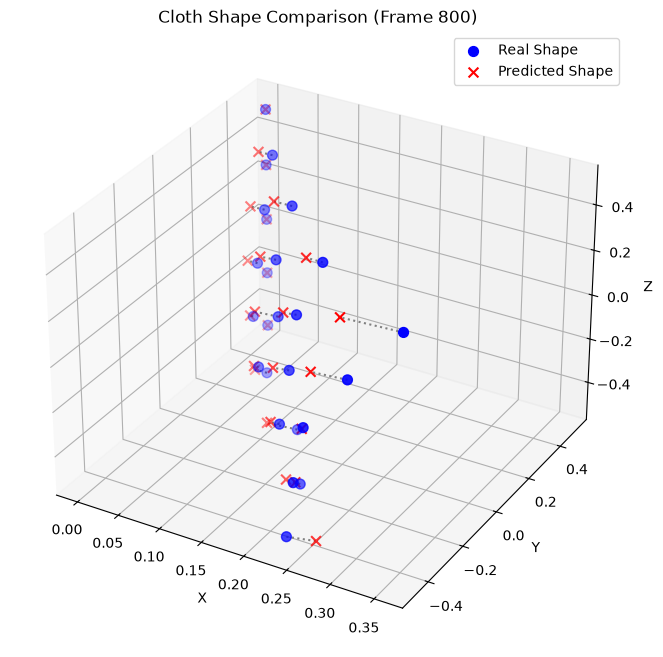

In [23]:
# Choose a random frame from your test set to visualize
frame_idx = 800 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

## 8. Export
Para poder usarse con Sentis en Unity se exporta a formato ONNX

In [ ]:
import torch
import Export

dummy_input = torch.randn
Export.ONNX_export(model, (1, seq_length, 1, optimal_n), output_path)

torch.Size([1, 16, 1, 16])
ONNX output shape: (1, 16)
ONNX export llevado a cabo con éxito.
